In [1]:
# Import libraries

import pandas as pd
import numpy as np


In [2]:
# Load dataset
df = pd.read_csv("delhi_air_pollution_data.csv" , encoding="latin1")

/tmp/ipykernel_2209/4125222617.py:2: DtypeWarning: Columns (2,3,4,5,6,8,9,10,13,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("delhi_air_pollution_data.csv" , encoding="latin1")


In [3]:
# Inspect dataset

# Displays first 10 rows
df.head(10)

# Display information
df.info()

# Number of rows and columns
df.shape

# columns Names
df.columns

# Missing values
df.isnull().sum()

# Duplicated rows
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229419 entries, 0 to 229418
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   datetime      229417 non-null  object 
 1   date          201607 non-null  object 
 2   year          201581 non-null  object 
 3   month         201570 non-null  object 
 4   day           201569 non-null  object 
 5   hour          201568 non-null  object 
 6   day_of_week   201566 non-null  object 
 7   is_weekend    201566 non-null  float64
 8   season        201566 non-null  object 
 9   city          201566 non-null  object 
 10  station       201566 non-null  object 
 11  latitude      201566 non-null  float64
 12  longitude     201566 non-null  float64
 13  pm25          201566 non-null  object 
 14  pm10          201564 non-null  float64
 15  no2           201564 non-null  float64
 16  so2           201564 non-null  float64
 17  co            201564 non-null  float64
 18  o3  

np.int64(27742)

In [4]:
# Remove Duplicates
df.drop_duplicates()

# Verify
df.duplicated().sum()

# New shape
df.shape

(229419, 25)

In [5]:
# Find corrupted values

# Shows last 10 rows
df.tail(10)

# Shows first 10 missing value rows
df[df.isnull().any(axis=1)].head(10)

# Shows rows from 201560 to 201677  and 201560 to 201570
df.loc[201560:201677]
df.loc[201560:201570]

# Gives all the rows upto 201567
df = df.iloc[:201567]
df.shape
# df.tail(10)

(201567, 25)

In [9]:
# Checking missing values again

df.isnull().sum()

df[df.isnull().any(axis=1)]

# Drop missing values
df = df.dropna()

# Verify
df.isnull().sum()
df.shape

(201564, 25)

In [10]:
# Fixing data types

# Converting datetime
df.dtypes

df["datetime"] = pd.to_datetime(df["datetime"])

df.dtypes

# Converting date
df["date"]=pd.to_datetime(df["date"])

df.dtypes

# Converting year
df["year"] = df["date"].dt.year

df.dtypes

# Converting month
df["month"] = df["date"].dt.month

df.dtypes

# Converting day
df["day"] = df["date"].dt.day

# Converting hour
df["hour"] = df["datetime"].dt.hour

# Converting pm25
df["pm25"] = df["pm25"].astype(float)

df.dtypes


,0
datetime,datetime64[ns]
date,datetime64[ns]
year,int32
month,int32
day,int32
hour,int32
day_of_week,object
is_weekend,float64
season,object
city,object


In [11]:
# Exploratory Data Analysis(EDA)

## Dataset overview

## 1.Check data types
df.dtypes

## Summarize all numerical values
df.describe()

## Checking unique values in categorical columns
df[['city','season','aqi_category']].nunique()


## Checking unique values
df['city'].unique()
df['season'].unique()
df['aqi_category'].unique()

#3 Transverse
df.describe().T

## Univariate Analysis
### Distribution of AQI Categories
df["aqi_category"].value_counts()



,count
aqi_category,
Severe,60002
Moderate,45397
Satisfactory,32860
Very Poor,29674
Poor,18843
Good,14788


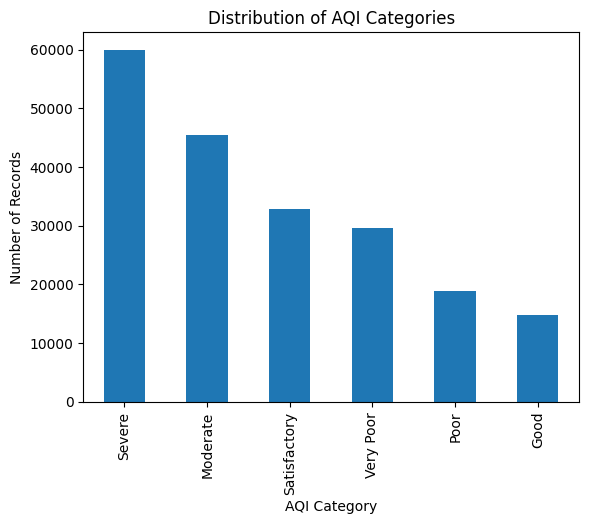

In [12]:
# VISUALIZE DATA

##Import library
import matplotlib.pyplot as plt

## Makes bar chart as Aqi category data is categorical
df["aqi_category"].value_counts().plot(kind="bar")

# Set the title and labels
plt.title("Distribution of AQI Categories")
plt.xlabel("AQI Category")
plt.ylabel("Number of Records")

# Displays graph
plt.show()

### Observations

- Severe AQI is the most common air quality category.
- Good AQI is the least common category.
- Most observations belong to polluted AQI categories (Poor, Very Poor, and Severe).
- The dataset contains all six AQI categories, indicating a wide variation in air quality across different locations and time periods.

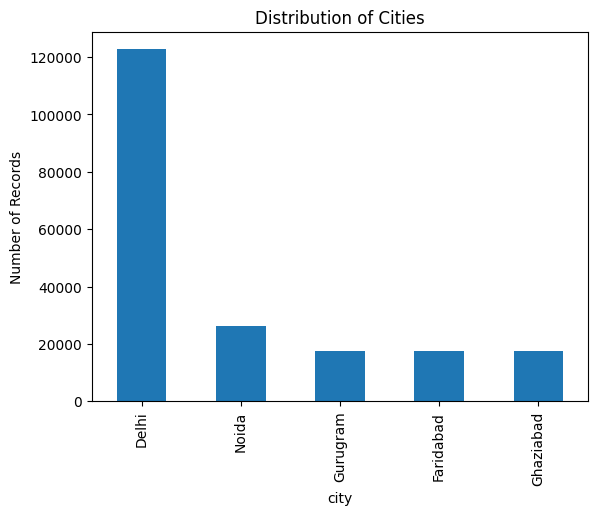

In [13]:
### City Distribution
df["city"].value_counts()

##Set the title and labels
plt.title("Distribution of Cities")
plt.xlabel("City")
plt.ylabel("Number of Records")

# Makes bar chart
df["city"].value_counts().plot(kind="bar")
plt.show()

### Observations

- Delhi has the highest number of records (122,694), making it the most represented city in the dataset.
- Noida is the second most represented city with 26,292 records.
- Gurugram, Faridabad, and Ghaziabad have nearly equal numbers of observations.
- The dataset is imbalanced, with Delhi contributing the majority of records.

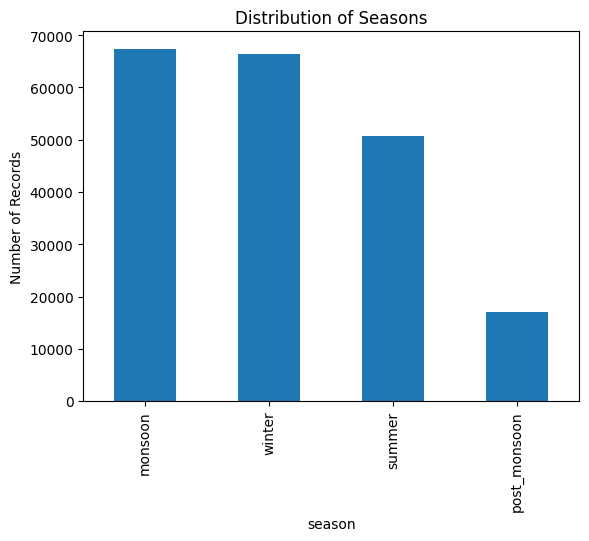

In [14]:
### Season Distribution
df["season"].value_counts()

##Set the title and labels
plt.title("Distribution of Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

# Makes bar chart
df["season"].value_counts().plot(kind="bar")
plt.show()

### Observations

- Monsoon has the highest number of observations (67,344).
- Winter is the second most represented season with 66,324 records.
- Summer contributes 50,784 observations.
- Post-monsoon has the fewest observations (17,112), making it the least represented season.
- The dataset is not evenly distributed across seasons.

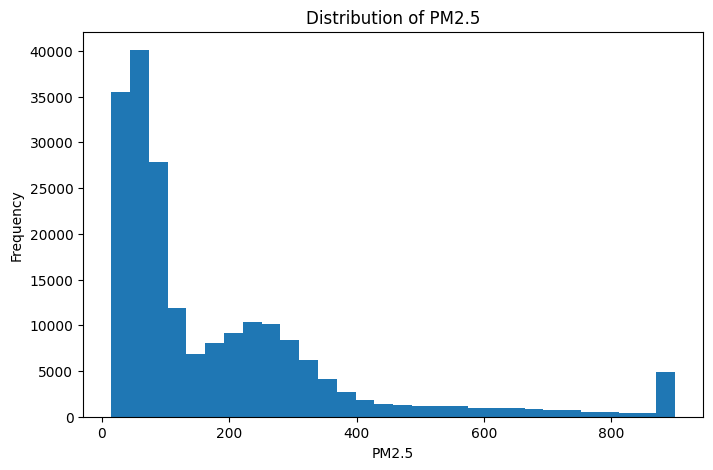

In [15]:
### PM25 distribution and visualization
plt.figure(figsize=(8,5))

plt.hist(df["pm25"], bins=30)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

Observations:

• The PM2.5 distribution is positively (right) skewed.

• Most PM2.5 values are concentrated between approximately 20 and 150.

• The frequency decreases as PM2.5 values increase.

• A few observations have extremely high PM2.5 values (around 900), indicating severe pollution events.
• The data is not normally distributed.

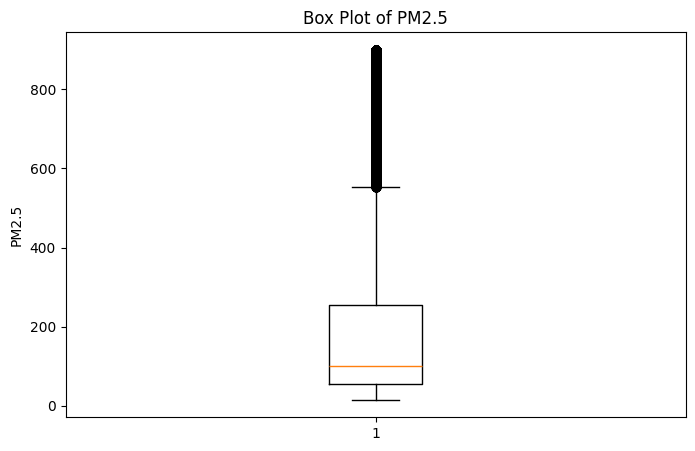

In [16]:
# Box plot using pm25

plt.figure(figsize=(8,5))
plt.boxplot(df['pm25'])
plt.title("Box Plot of PM2.5")
plt.ylabel("PM2.5")
plt.show()

Observations:

• The median PM2.5 value is around 100.

• The middle 50% of PM2.5 values lie roughly between 50 and 250 (Interquartile Range).

• The box plot shows a large number of outliers above the upper whisker.

• These outliers represent days with extremely high pollution levels.

• Since these values are likely real environmental observations rather than data entry errors, they are retained for further analysis.

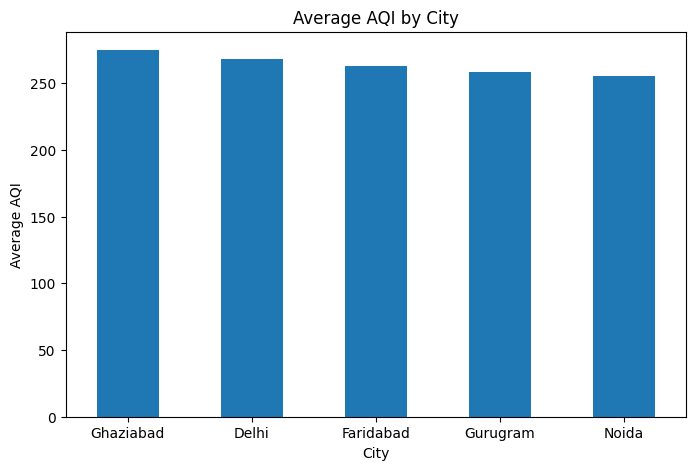

In [17]:
# Relationship analysis - EDA

## Calculate Average AQI
city_aqi = df.groupby("city")["aqi"].mean().sort_values(ascending=False)
city_aqi

# visualize it
city_aqi.plot(kind="bar", figsize=(8,5))

plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)

plt.show()

Observations:

• Ghaziabad has the highest average AQI (274.90), indicating the poorest air quality among the five cities.

• Delhi has the second-highest average AQI (267.99), showing consistently high pollution levels.

• Noida has the lowest average AQI (255.76), making it the least polluted city in this dataset.

• The average AQI values of all five cities are above 250, indicating generally poor air quality across the Delhi NCR region.

• Although the differences between cities are not very large, Ghaziabad consistently records the highest pollution levels.

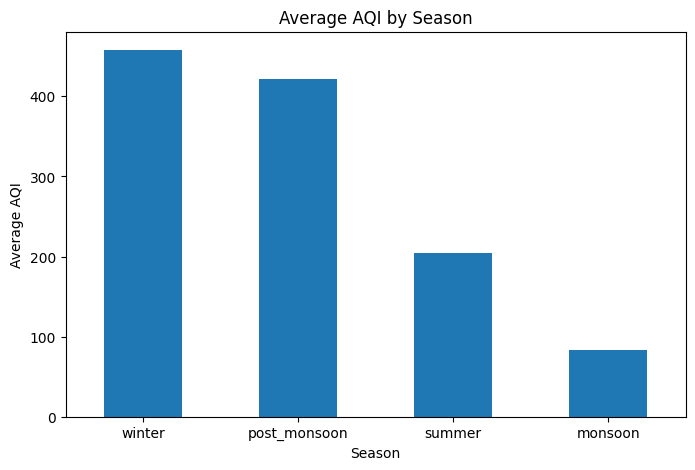

In [18]:
#Average AQI By Season

season_aqi = df.groupby("season")["aqi"].mean().sort_values(ascending=False)
season_aqi

# Visualuze it
season_aqi.plot(kind="bar", figsize=(8,5))

plt.title("Average AQI by Season")
plt.xlabel("Season")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)

plt.show()


Observations:

• Winter has the highest average AQI (457.72), indicating the worst air quality among all seasons.

• Post-monsoon also records very high pollution levels with an average AQI of 421.81.

• Summer has a moderate average AQI of 204.79.

• Monsoon has the lowest average AQI (82.89), indicating the cleanest air due to rainfall, which helps remove pollutants from the atmosphere.

• The analysis shows that air pollution is strongly influenced by seasonal changes.

In [19]:
# Coorelation Analysis

## Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

numeric_df.head()

## Coorelation matrix
corr_matrix = numeric_df.corr()

corr_matrix

,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
year,1.000000,-0.000595,-0.000352,0.000007,-0.000884,-0.000061,-0.000041,-0.020785,-0.020755,-0.019306,-0.018291,-0.020105,0.004916,0.001374,-0.000449,0.002184,0.023913,-0.023263
month,-0.000595,1.000000,0.010113,0.000007,-0.002020,-0.000056,-0.000037,0.337972,0.335594,0.325668,0.329464,0.327108,-0.397502,0.090848,0.195732,-0.205964,-0.025869,0.115383
day,-0.000352,0.010113,1.000000,0.000005,0.001021,-0.000005,-0.000001,-0.002084,-0.002391,-0.002324,-0.000994,-0.002244,-0.011706,0.005313,-0.004073,0.008376,-0.012686,0.026423
hour,0.000007,0.000007,0.000005,1.000000,0.000017,0.000003,0.000001,-0.006544,-0.006379,0.030777,-0.006599,0.037383,-0.102182,0.170985,-0.336041,0.141057,-0.008768,0.017191
is_weekend,-0.000884,-0.002020,0.001021,0.000017,1.000000,0.000017,-0.000001,-0.037572,-0.037275,-0.078410,-0.035091,-0.037609,0.009417,0.000775,-0.001655,0.000446,0.039926,-0.039682
latitude,-0.000061,-0.000056,-0.000005,0.000003,0.000017,1.000000,-0.220573,0.040337,0.040102,0.038958,0.101718,0.038658,-0.016060,0.000368,0.000208,0.000145,-0.042302,0.042592
longitude,-0.000041,-0.000037,-0.000001,0.000001,-0.000001,-0.220573,1.000000,0.005245,0.005327,0.004536,-0.000612,0.004989,-0.002603,-0.000308,0.000095,-0.000020,-0.005524,0.005964
pm25,-0.020785,0.337972,-0.002084,-0.006544,-0.037572,0.040337,0.005245,1.000000,0.992216,0.962833,0.958428,0.965569,-0.362016,-0.517646,-0.042698,-0.469890,-0.672341,0.800749
pm10,-0.020755,0.335594,-0.002391,-0.006379,-0.037275,0.040102,0.005327,0.992216,1.000000,0.955432,0.951141,0.958195,-0.359434,-0.513688,-0.042167,-0.466324,-0.667176,0.797859
no2,-0.019306,0.325668,-0.002324,0.030777,-0.078410,0.038958,0.004536,0.962833,0.955432,1.000000,0.923130,0.967651,-0.355520,-0.490849,-0.069603,-0.450295,-0.648299,0.773434


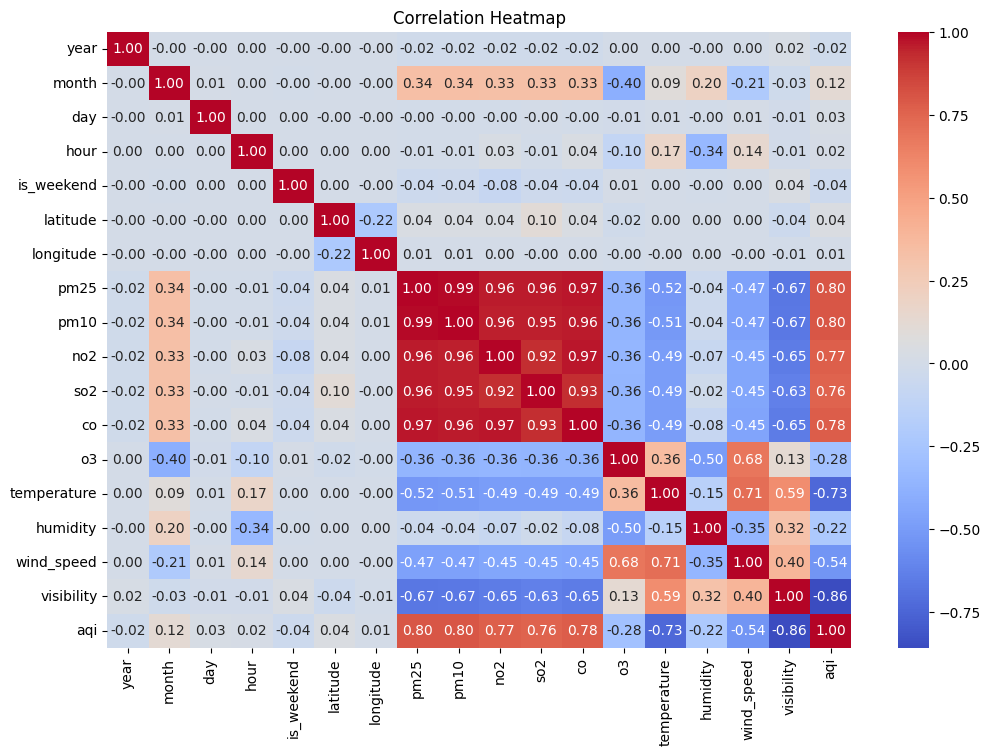

In [20]:
## Heatmap
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observations

- PM2.5, PM10, NO2, SO2, and CO show a very strong positive correlation with each other (0.92–0.99), indicating that these pollutants often increase together.
- AQI has a strong positive correlation with PM2.5 (0.80), PM10 (0.80), CO (0.78), NO2 (0.77), and SO2 (0.76), suggesting that higher pollutant concentrations lead to poorer air quality.
- Visibility has the strongest negative correlation with AQI (-0.86), indicating that air quality deteriorates as visibility decreases.
- Temperature is negatively correlated with AQI (-0.73), implying that pollution levels are generally higher during colder periods.
- Wind speed also shows a moderate negative correlation with AQI (-0.54), suggesting stronger winds help disperse pollutants.
- Ozone (O3) has a weak negative correlation with AQI (-0.28) and moderate positive correlation with wind speed (0.68), indicating different behavior compared to other pollutants.
- Humidity has a weak negative relationship with AQI (-0.22), showing limited influence on overall air quality.
- Temporal features such as year, day, hour, and weekend have very weak correlations with AQI and pollutant concentrations.

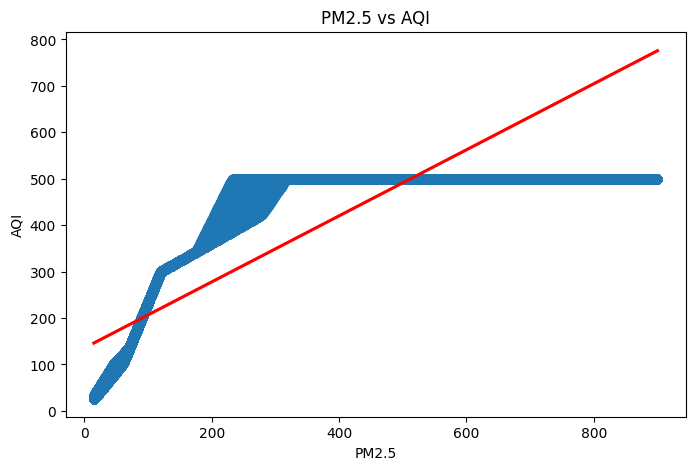

In [21]:
## Scatter Plot Analysis

### AQI vs PM25
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='pm25',
    y='aqi',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")

plt.show()

### Observations: PM2.5 vs AQI Scatter Plot

- PM2.5 shows a clear positive relationship with AQI, indicating that higher PM2.5 concentrations generally result in poorer air quality.
- AQI increases rapidly as PM2.5 levels rise in the lower concentration range.
- The fitted regression line confirms a strong positive linear trend between PM2.5 and AQI.
- AQI values become capped around 500 despite further increases in PM2.5, suggesting the dataset follows the standard AQI upper limit.
- PM2.5 appears to be one of the major contributors to AQI variations.

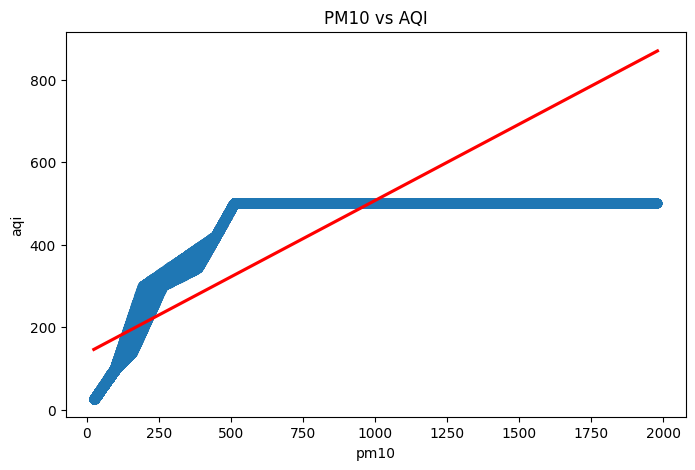

In [22]:
## PM VS AQI

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='pm10',
    y='aqi',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("PM10 vs AQI")
plt.show()

### Observations

- PM10 exhibits a strong positive relationship with AQI, with higher PM10 concentrations associated with poorer air quality.
- The regression line indicates a clear increasing trend between PM10 and AQI.
- AQI reaches its maximum value of approximately 500 even when PM10 continues to increase, indicating AQI saturation at its upper limit.
- The relationship suggests that PM10 is a significant factor influencing overall air quality.
- Higher PM10 concentrations are consistently associated with unhealthy air quality conditions.

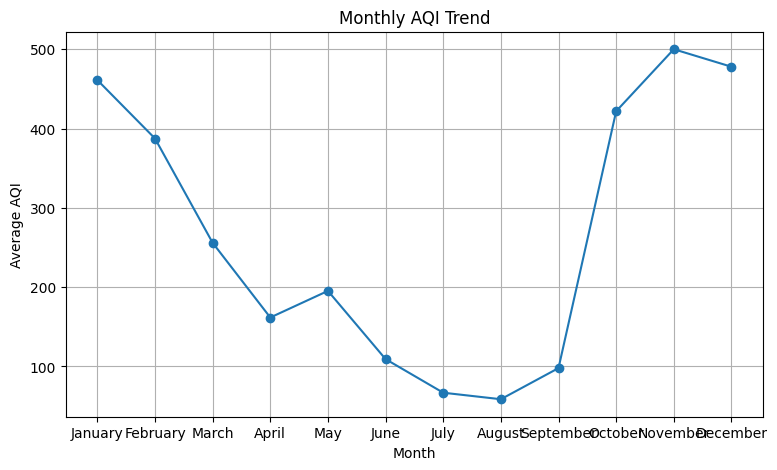

In [23]:
## Month wise AQI trend

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_aqi = df.groupby("month")["aqi"].mean().reset_index()
plt.figure(figsize=(9,5))
plt.plot(monthly_aqi["month"], monthly_aqi["aqi"], marker="o")
plt.title("Monthly AQI Trend")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True)
plt.xticks(range(1,13), month_order)
plt.show()



### Observations

- AQI is highest during November, December, and January, indicating severe air pollution during winter months.
- Air quality gradually improves from February to August, reaching the lowest AQI during July and August.
- A sharp increase in AQI is observed from September to October, marking the beginning of the winter pollution season.
- Summer and monsoon months generally experience better air quality compared to winter.
- The monthly trend clearly demonstrates a strong seasonal variation in air pollution levels.



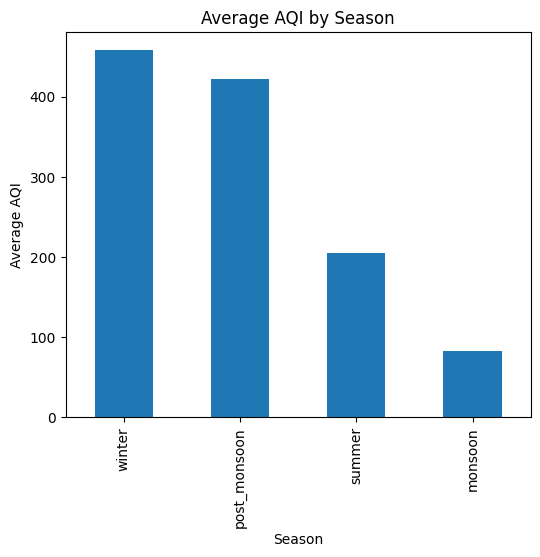

In [24]:
## Average AQI by season

season_avg = df.groupby("season")["aqi"].mean().sort_values(ascending=False)

plt.figure(figsize=(6,5))
season_avg.plot(kind="bar")
plt.title("Average AQI by Season")
plt.xlabel("Season")
plt.ylabel("Average AQI")
plt.show()




### Observations

- Winter records the highest average AQI, indicating the poorest air quality among all seasons.
- Post-monsoon also experiences very high AQI levels, second only to winter.
- Summer shows moderate AQI values, reflecting comparatively cleaner air.
- Monsoon has the lowest average AQI, suggesting rainfall and stronger atmospheric mixing help remove pollutants.
- Overall, air quality follows the pattern: Winter > Post-Monsoon > Summer > Monsoon.





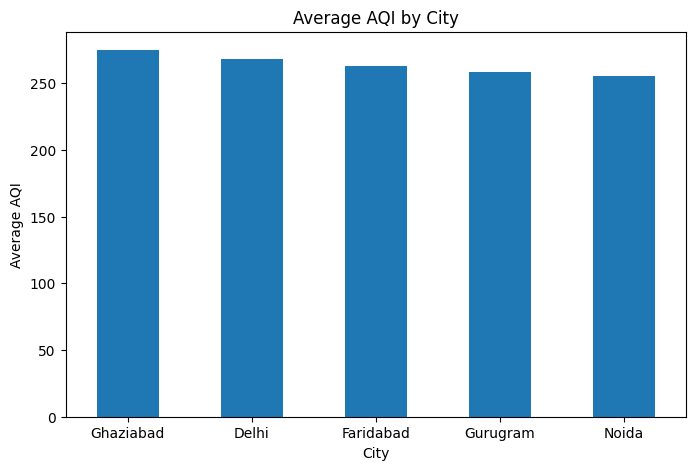

In [25]:
## Average AQI By City

city_aqi = df.groupby("city")["aqi"].mean().sort_values(ascending=False)

plt.figure(figsize = (8,5))
city_aqi.plot(kind="bar")
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)
plt.show()

### Observations

- Ghaziabad has the highest average AQI, indicating the poorest air quality among the five cities.
- Delhi records the second-highest average AQI, followed by Faridabad and Gurugram.
- Noida has the lowest average AQI in the dataset.
- Although there are differences among the cities, all of them have relatively high average AQI values, indicating widespread air pollution across the Delhi NCR region.





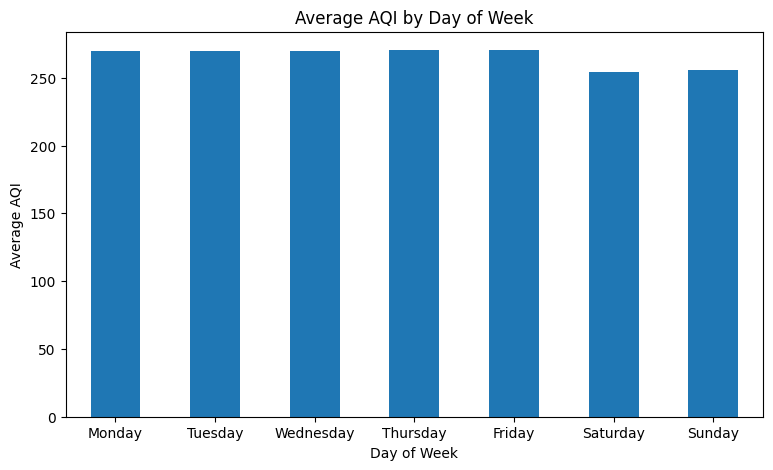

In [26]:
## Average AQI by Day of Week

day_aqi = df.groupby("day_of_week")["aqi"].mean()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_aqi = day_aqi.reindex(day_order)

plt.figure(figsize=(9,5))
day_aqi.plot(kind="bar")
plt.title("Average AQI by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)
plt.show()

### Observations

- AQI remains relatively consistent throughout the week with only minor variations.
- Weekdays generally show slightly higher AQI values compared to weekends.
- Saturday and Sunday exhibit a small reduction in average AQI, possibly due to reduced traffic and industrial activities.
- Overall, the variation across different days of the week is not significant.

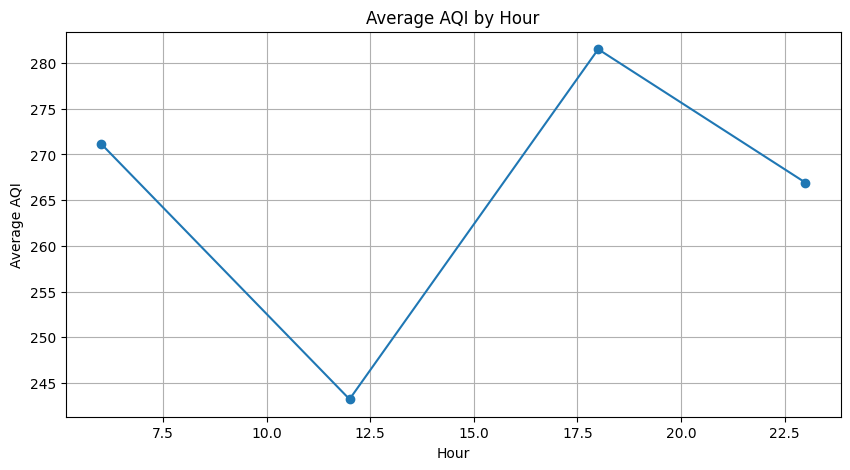

In [27]:
## Average AQI BY Hour

hourly_aqi = df.groupby("hour")["aqi"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_aqi.index, hourly_aqi.values, marker="o")
plt.title("Average AQI by Hour")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

### Observations

- AQI is generally higher during the early morning and late evening hours.
- Pollution levels decrease during the afternoon, when atmospheric mixing helps disperse pollutants.
- The hourly trend indicates noticeable variations in air quality throughout the day.
- Peak AQI during morning and evening hours may be influenced by traffic emissions and unfavorable atmospheric conditions.

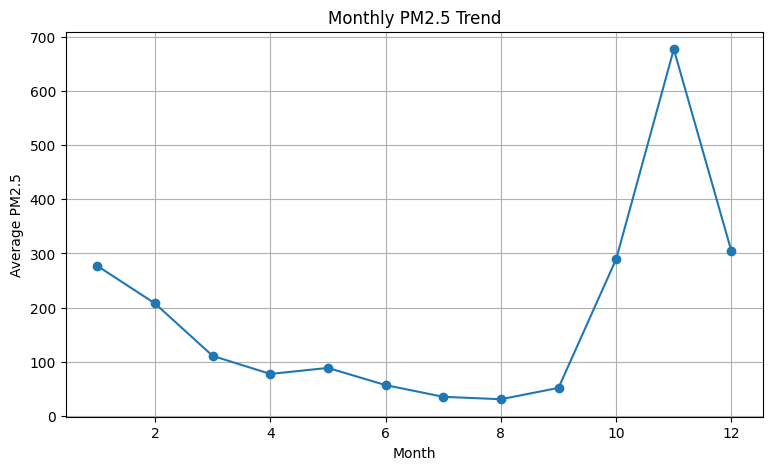

In [28]:
## POLLUTANT ANALYSIS

### Monthly PM2.5 Trend

monthly_pm25 = df.groupby("month")["pm25"].mean()

plt.figure(figsize=(9,5))
monthly_pm25.plot(marker = "o")
plt.title("Monthly PM2.5 Trend")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.grid(True)
plt.show()

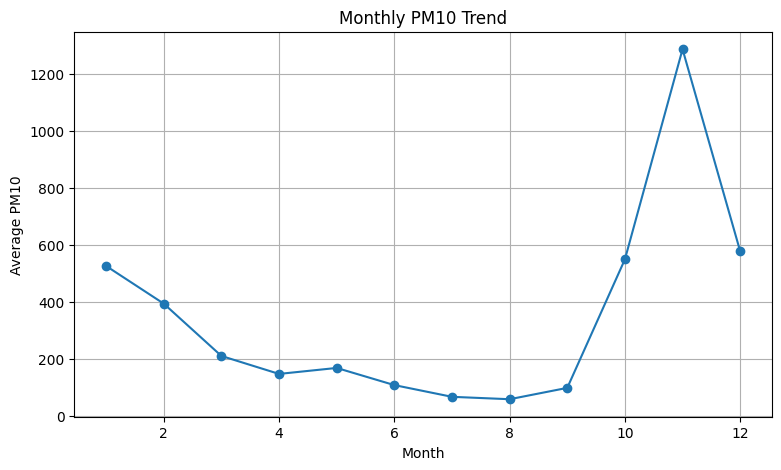

In [29]:
### Monthly PM10 Trend

monthly_pm10 = df.groupby("month")["pm10"].mean()

plt.figure(figsize=(9,5))
monthly_pm10.plot(marker = "o")
plt.title("Monthly PM10 Trend")
plt.xlabel("Month")
plt.ylabel("Average PM10")
plt.grid(True)
plt.show()

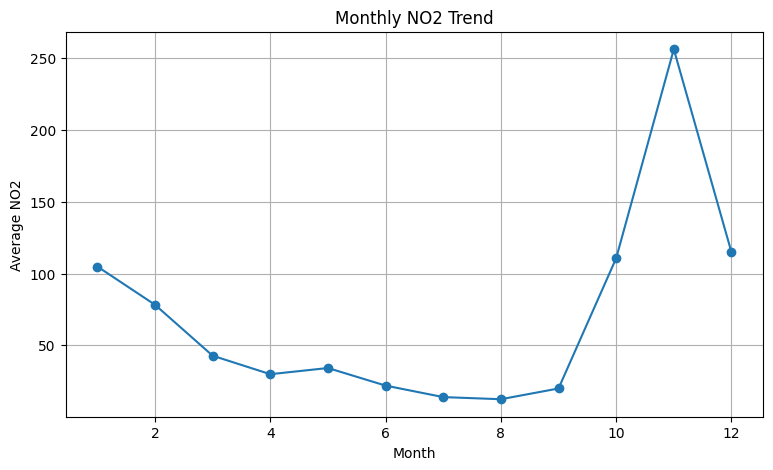

In [30]:
## Monthly NO2 Trend

monthly_no2 = df.groupby("month")["no2"].mean()

plt.figure(figsize=(9,5))
monthly_no2.plot(marker = "o")
plt.title("Monthly NO2 Trend")
plt.xlabel("Month")
plt.ylabel("Average NO2")
plt.grid(True)
plt.show()


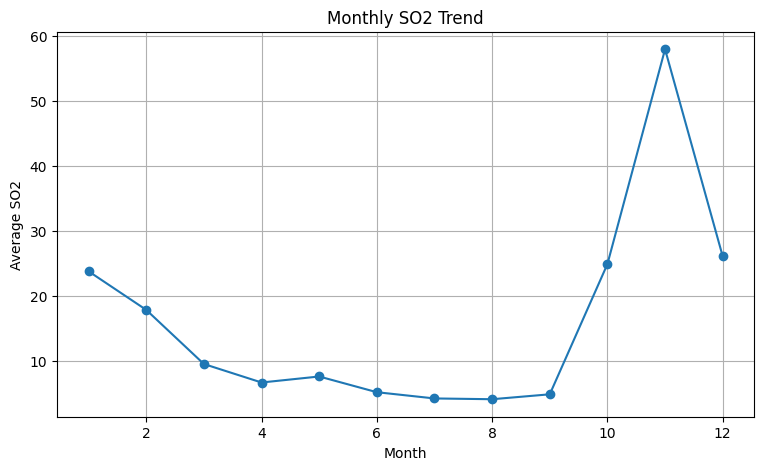

In [31]:
## Monthly SO2 Trend

monthly_so2 = df.groupby("month")["so2"].mean()

plt.figure(figsize=(9,5))
monthly_so2.plot(marker = "o")
plt.title("Monthly SO2 Trend")
plt.xlabel("Month")
plt.ylabel("Average SO2")
plt.grid(True)
plt.show()

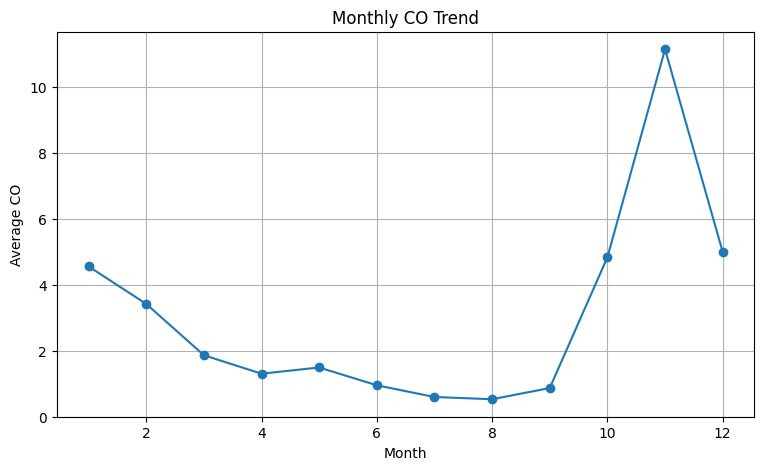

In [32]:
## Monthly CO Trend

monthly_co = df.groupby("month")["co"].mean()

plt.figure(figsize=(9,5))
monthly_co.plot(marker = "o")
plt.title("Monthly CO Trend")
plt.xlabel("Month")
plt.ylabel("Average CO")
plt.grid(True)
plt.show()


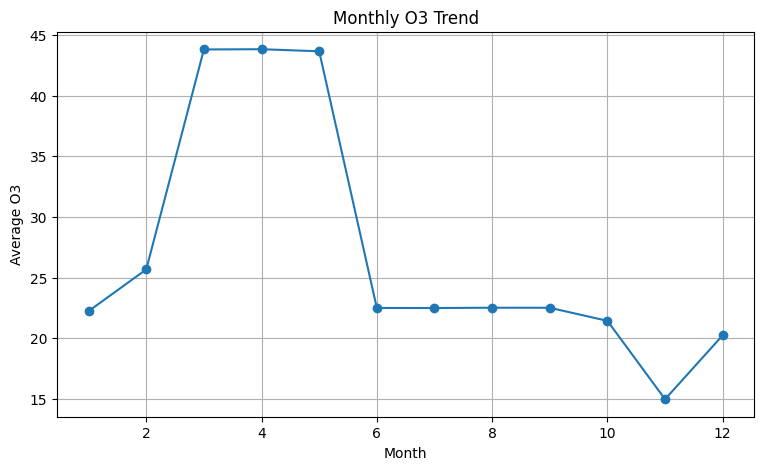

In [33]:
## Monthly O3 Trend

monthly_o3 = df.groupby("month")["o3"].mean()

plt.figure(figsize=(9,5))
monthly_o3.plot(marker = "o")
plt.title("Monthly O3 Trend")
plt.xlabel("Month")
plt.ylabel("Average O3")
plt.grid(True)
plt.show()

Business Insights:

1. PM2.5 concentrations remained lowest during July and August but increased sharply from October, reaching the highest level in November.

2. PM10 followed a similar seasonal pattern as PM2.5, indicating that particulate pollution intensifies significantly during late autumn and early winter.

3. NO2 levels peaked in November, suggesting increased emissions from vehicles and industrial activities during winter months.

4. SO2 concentrations were relatively stable for most of the year but showed a significant spike in November.

5. Carbon Monoxide (CO) reached its highest average value in November, reflecting poor atmospheric dispersion and increased fuel combustion.

6. Ozone (O3) showed an opposite trend compared to other pollutants, recording its highest values during March–May and lowest during winter.

7. Most pollutants exhibited a clear seasonal pattern, with cleaner air during the monsoon months and severe pollution during winter.

8. November consistently recorded the highest concentration across PM2.5, PM10, NO2, SO2 and CO, making it the most polluted month.

9. July and August experienced the best air quality due to rainfall and improved pollutant dispersion.

10. The inverse relationship between O3 and particulate pollutants indicates different atmospheric formation mechanisms.

11. Winter weather conditions such as low temperature, low wind speed and temperature inversion likely contributed to pollutant accumulation.

12. The simultaneous increase in multiple pollutants suggests that common emission sources, such as traffic, industries and biomass burning, influence Delhi's air quality.

13. Seasonal analysis can help authorities identify high-risk periods requiring stricter pollution control measures.

14. Continuous monitoring of pollutant trends enables better forecasting and policy planning.

15. Data visualization clearly highlights recurring yearly pollution cycles, supporting evidence-based environmental decision-making.

Recommendations:

• Implement stricter vehicle emission controls, especially from October to December.

• Promote public transportation, electric vehicles and carpooling to reduce traffic-related emissions.

• Enforce regulations against crop residue burning and illegal waste burning during winter.

• Increase industrial emission monitoring during high-pollution months.

• Expand urban green spaces and tree plantations to improve air quality.

• Issue public health advisories during severe pollution episodes.

• Encourage remote work or staggered office timings during extreme AQI days.

• Install additional real-time air quality monitoring stations across the city.

• Increase awareness campaigns promoting pollution-reducing practices.

• Use predictive analytics to forecast pollution spikes and support early intervention.

Conclusion:

This project analyzed Delhi's air pollution data using Python and Pandas by performing data cleaning, exploratory data analysis (EDA), and visualization. The analysis revealed strong seasonal variations in pollutant concentrations, with PM2.5, PM10, NO2, SO2 and CO reaching their highest levels during November, while ozone peaked during the summer months. The findings highlight the significant impact of seasonal and human activities on air quality and demonstrate how data analytics can support environmental monitoring and policy decisions. This project showcases practical skills in data cleaning, analysis, visualization and deriving actionable insights from real-world environmental data.

In [34]:
# Save cleaned dataset
df.to_csv("delhi_air_pollution_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
